# EXP3 — Final Compiled Results
Aggregates **pre-calibration** and **post-calibration** metrics from all four EXP3 notebooks:
- **A** · KNN + Random Forest (`exp3_knn_rf`)
- **B** · XGBoost + AdaBoost (`exp3_xgb_ada`)
- **C** · Logistic Regression + CatBoost + LightGBM (`exp3_logreg_cat`)
- **D** · Naïve Bayes (`exp3_naive_bayes`)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# Resolve paths so this notebook works when FINAL is used standalone
CWD = Path.cwd()
if (CWD / 'Datasets2015').exists():
    WORKSPACE = CWD
elif (CWD / 'FINAL' / 'Datasets2015').exists():
    WORKSPACE = CWD / 'FINAL'
elif (CWD.parent / 'Datasets2015').exists():
    WORKSPACE = CWD.parent
else:
    raise FileNotFoundError(
        "Could not locate Datasets2015. Run this notebook from FINAL or its parent folder."
    )

EXP_DIRS = {
    'A · KNN / RF':            WORKSPACE / 'exp3_knn_rf',
    'B · XGBoost / AdaBoost':  WORKSPACE / 'exp3_xgb_ada',
    'C · LogReg / CatBoost':   WORKSPACE / 'exp3_logreg_cat',
    'D · Naïve Bayes':         WORKSPACE / 'exp3_naive_bayes',
}

OUT_DIR = WORKSPACE / 'exp3_compiled'
PLOT_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

METRIC_COLS = ['accuracy', 'recall', 'precision', 'f1', 'auc', 'logloss', 'ece']

print('Workspace directory:', WORKSPACE)
print('Output directory:', OUT_DIR)
print('Experiments:', list(EXP_DIRS.keys()))

Output directory: /workspace/Thesis-part-2/exp3_compiled
Experiments: ['A · KNN / RF', 'B · XGBoost / AdaBoost', 'C · LogReg / CatBoost', 'D · Naïve Bayes']


## 1 · Load & Compile Pre-Calibration Results

In [11]:
# ── Load pre-calibration CSVs ─────────────────────────────────────────────────
pre_frames = []

for exp_label, exp_dir in EXP_DIRS.items():
    csv_path = exp_dir / 'pre_calibration_results.csv'
    if not csv_path.exists():
        print(f'  MISSING: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    df.insert(0, 'experiment', exp_label)
    pre_frames.append(df)
    print(f'  Loaded {len(df):3d} rows  ←  {csv_path.relative_to(WORKSPACE)}')

pre_all = pd.concat(pre_frames, ignore_index=True)

# Recompute combined using consistent formula: mean(acc, rec, 1-ece, 1-logloss)
pre_all['combined'] = (
    pre_all['accuracy'] + pre_all['recall'] +
    (1 - pre_all['ece']) + (1 - pre_all['logloss'])
) / 4.0

pre_all = (
    pre_all
    .sort_values(['combined', 'auc'], ascending=False)
    .reset_index(drop=True)
)
pre_all.index += 1

# ── Save ─────────────────────────────────────────────────────────────────────
_out = OUT_DIR / 'compiled_pre_calibration_results.csv'
pre_all.to_csv(_out, index=True, index_label='rank')
print(f'\nSaved  →  {_out}  ({len(pre_all)} rows total)')

print('\n' + '='*100)
print('PRE-CALIBRATION — ALL MODELS (sorted by mean(acc, rec, 1-ece, 1-logloss))')
print('='*100)
display(pre_all[['experiment','sampling','model','threshold',
                  'accuracy','recall','precision','f1','auc','logloss','ece','combined']])

  Loaded  12 rows  ←  exp3_knn_rf/pre_calibration_results.csv
  Loaded  12 rows  ←  exp3_xgb_ada/pre_calibration_results.csv
  Loaded  18 rows  ←  exp3_logreg_cat/pre_calibration_results.csv
  Loaded   6 rows  ←  exp3_naive_bayes/pre_calibration_results.csv

Saved  →  /workspace/Thesis-part-2/exp3_compiled/compiled_pre_calibration_results.csv  (48 rows total)

PRE-CALIBRATION — ALL MODELS (sorted by mean(acc, rec, 1-ece, 1-logloss))


,experiment,sampling,model,threshold,accuracy,recall,precision,f1,auc,logloss,ece,combined
1,A · KNN / RF,cw,randomforest,0.3500,0.7307,0.8553,0.3446,0.4913,0.8487,0.3691,0.1171,0.7749
2,C · LogReg / CatBoost,smote,lightgbm,0.3500,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7713
3,C · LogReg / CatBoost,smotenc,lightgbm,0.3500,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7713
4,C · LogReg / CatBoost,smotecw,lightgbm,0.3500,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7713
5,C · LogReg / CatBoost,smotencw,lightgbm,0.3500,0.7295,0.8375,0.3413,0.4849,0.8378,0.3705,0.1111,0.7713
6,B · XGBoost / AdaBoost,smote,xgboost,0.3500,0.7289,0.8358,0.3405,0.4838,0.8378,0.3704,0.1095,0.7712
7,B · XGBoost / AdaBoost,smotenc,xgboost,0.3500,0.7289,0.8358,0.3405,0.4838,0.8378,0.3704,0.1095,0.7712
8,B · XGBoost / AdaBoost,smotecw,xgboost,0.3500,0.7289,0.8358,0.3405,0.4838,0.8378,0.3704,0.1095,0.7712
9,B · XGBoost / AdaBoost,smotencw,xgboost,0.3500,0.7289,0.8358,0.3405,0.4838,0.8378,0.3704,0.1095,0.7712
10,A · KNN / RF,smote,randomforest,0.3500,0.7080,0.8795,0.3282,0.4780,0.8347,0.4003,0.1356,0.7629


## 2 · Load & Compile Post-Calibration Results

In [12]:
# ── Load post-calibration CSVs ────────────────────────────────────────────────
post_frames = []

for exp_label, exp_dir in EXP_DIRS.items():
    csv_path = exp_dir / 'post_calibration_results.csv'
    if not csv_path.exists():
        print(f'  MISSING: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    df.insert(0, 'experiment', exp_label)
    post_frames.append(df)
    print(f'  Loaded {len(df):3d} rows  ←  {csv_path.relative_to(WORKSPACE)}')

post_all = pd.concat(post_frames, ignore_index=True)

# Recompute combined using consistent formula: mean(acc, rec, 1-ece, 1-logloss)
post_all['combined'] = (
    post_all['accuracy'] + post_all['recall'] +
    (1 - post_all['ece']) + (1 - post_all['logloss'])
) / 4.0

post_all = (
    post_all
    .sort_values(['combined', 'auc'], ascending=False)
    .reset_index(drop=True)
)
post_all.index += 1

# ── Save ─────────────────────────────────────────────────────────────────────
_out = OUT_DIR / 'compiled_post_calibration_results.csv'
post_all.to_csv(_out, index=True, index_label='rank')
print(f'\nSaved  →  {_out}  ({len(post_all)} rows total)')

print('\n' + '='*100)
print('POST-CALIBRATION — ALL MODELS (sorted by mean(acc, rec, 1-ece, 1-logloss))')
print('='*100)
display(post_all[['experiment','sampling','model','calibration',
                   'accuracy','recall','precision','f1','auc','logloss','ece','combined']])

  Loaded  48 rows  ←  exp3_knn_rf/post_calibration_results.csv
  Loaded  48 rows  ←  exp3_xgb_ada/post_calibration_results.csv
  Loaded  72 rows  ←  exp3_logreg_cat/post_calibration_results.csv
  Loaded  24 rows  ←  exp3_naive_bayes/post_calibration_results.csv

Saved  →  /workspace/Thesis-part-2/exp3_compiled/compiled_post_calibration_results.csv  (192 rows total)

POST-CALIBRATION — ALL MODELS (sorted by mean(acc, rec, 1-ece, 1-logloss))


,experiment,sampling,model,calibration,accuracy,recall,precision,f1,auc,logloss,ece,combined
1,A · KNN / RF,cw,randomforest,base,0.7968,0.6774,0.4005,0.5034,0.8487,0.3691,0.1171,0.7470
2,B · XGBoost / AdaBoost,cw,xgboost,base,0.7687,0.7651,0.3729,0.5014,0.8469,0.4118,0.1493,0.7432
3,C · LogReg / CatBoost,smote,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
4,C · LogReg / CatBoost,smotenc,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
5,C · LogReg / CatBoost,smotecw,catboost,base,0.7521,0.7822,0.3564,0.4897,0.8375,0.4139,0.1577,0.7407
...,...,...,...,...,...,...,...,...,...,...,...,...
188,D · Naïve Bayes,smotencw,naive_bayes,platt,0.8480,0.0000,0.0000,0.0000,0.7922,0.3536,0.0116,0.6207
189,D · Naïve Bayes,smote,naive_bayes,base,0.7309,0.7451,0.3296,0.4570,0.7922,0.7991,0.2120,0.6162
190,D · Naïve Bayes,smotenc,naive_bayes,base,0.7309,0.7451,0.3296,0.4570,0.7922,0.7991,0.2120,0.6162
191,D · Naïve Bayes,smotecw,naive_bayes,base,0.7309,0.7451,0.3296,0.4570,0.7922,0.7991,0.2120,0.6162


Saved  →  /workspace/Thesis-part-2/exp3_compiled/compiled_post_calibration_by_avg_cal_metric.csv  (192 rows)

POST-CALIBRATION — ALL MODELS sorted by Average Calibration Metric  =  mean(ECE, Log-Loss)  (lower = better)


,experiment,sampling,model,calibration,accuracy,recall,precision,f1,auc,ece,logloss,avg_cal_metric,combined
1,B · XGBoost / AdaBoost,base,xgboost,base,0.8502,0.1190,0.5321,0.1945,0.8519,0.0027,0.3098,0.1562,0.6642
2,C · LogReg / CatBoost,base,lightgbm,base,0.8500,0.1157,0.5299,0.1900,0.8521,0.0041,0.3095,0.1568,0.6630
3,C · LogReg / CatBoost,base,lightgbm,venn_abers,0.8503,0.1497,0.5268,0.2331,0.8518,0.0038,0.3101,0.1570,0.6715
4,C · LogReg / CatBoost,base,lightgbm,isotonic,0.8504,0.1497,0.5276,0.2332,0.8517,0.0043,0.3101,0.1572,0.6714
5,C · LogReg / CatBoost,cw,lightgbm,venn_abers,0.8506,0.1083,0.5425,0.1806,0.8519,0.0036,0.3114,0.1575,0.6610
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,D · Naïve Bayes,cw,naive_bayes,base,0.7463,0.7300,0.3429,0.4666,0.8075,0.1859,0.7084,0.4472,0.6455
189,D · Naïve Bayes,smote,naive_bayes,base,0.7309,0.7451,0.3296,0.4570,0.7922,0.2120,0.7991,0.5056,0.6162
190,D · Naïve Bayes,smotenc,naive_bayes,base,0.7309,0.7451,0.3296,0.4570,0.7922,0.2120,0.7991,0.5056,0.6162
191,D · Naïve Bayes,smotecw,naive_bayes,base,0.7309,0.7451,0.3296,0.4570,0.7922,0.2120,0.7991,0.5056,0.6162


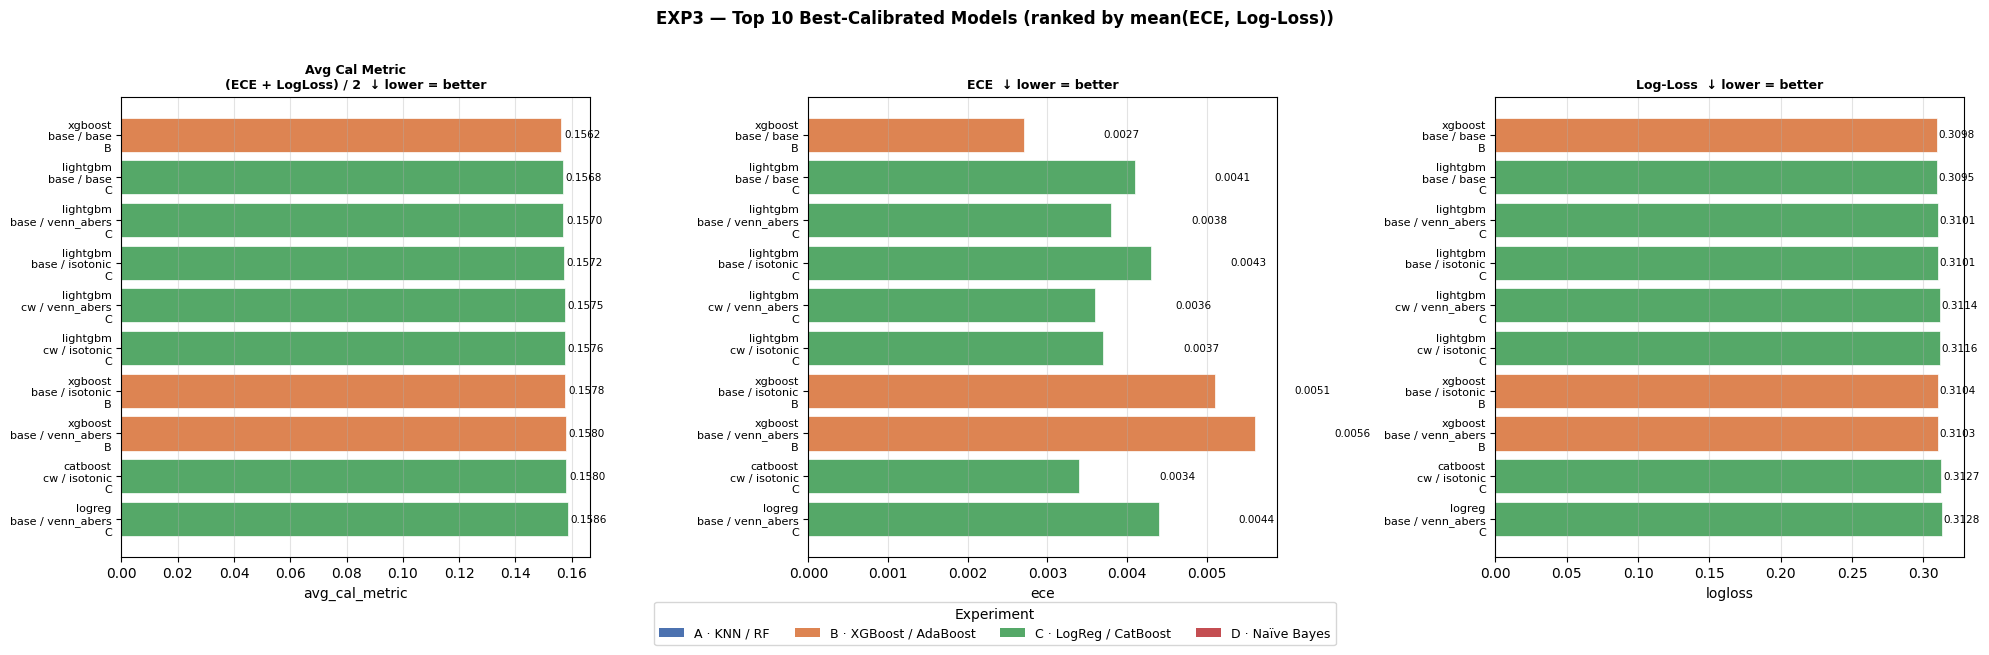

Saved: /workspace/Thesis-part-2/exp3_compiled/plots/top10_best_calibrated_bar.png


In [13]:
# ── Post-Calibration Results sorted by Average Calibration Metrics ────────────
# avg_cal_metric = mean(ECE, log-loss)  →  lower = better calibration
# Table is ranked best-to-worst calibration quality.

post_cal_sorted = post_all.copy()
post_cal_sorted['avg_cal_metric'] = (
    post_cal_sorted['ece'] + post_cal_sorted['logloss']
) / 2.0

post_cal_sorted = (
    post_cal_sorted
    .sort_values(['avg_cal_metric', 'auc'], ascending=[True, False])
    .reset_index(drop=True)
)
post_cal_sorted.index += 1

# Save
_out = OUT_DIR / 'compiled_post_calibration_by_avg_cal_metric.csv'
post_cal_sorted.to_csv(_out, index=True, index_label='rank')
print(f'Saved  →  {_out}  ({len(post_cal_sorted)} rows)')

print('\n' + '='*110)
print('POST-CALIBRATION — ALL MODELS sorted by Average Calibration Metric  =  mean(ECE, Log-Loss)  (lower = better)')
print('='*110)
display(post_cal_sorted[[
    'experiment', 'sampling', 'model', 'calibration',
    'accuracy', 'recall', 'precision', 'f1', 'auc',
    'ece', 'logloss', 'avg_cal_metric', 'combined'
]])

# ── Top-10 best-calibrated bar chart ─────────────────────────────────────────
top10_cal = post_cal_sorted.head(10).copy()
top10_cal['label'] = (
    top10_cal['model'] + '\n' +
    top10_cal['sampling'] + ' / ' + top10_cal['calibration'] + '\n' +
    top10_cal['experiment'].str.extract(r'^(\w+)', expand=False)
)

colors_exp = {
    'A · KNN / RF':            '#4C72B0',
    'B · XGBoost / AdaBoost':  '#DD8452',
    'C · LogReg / CatBoost':   '#55A868',
    'D · Naïve Bayes':         '#C44E52',
}
bar_colors_cal = [colors_exp.get(e, '#888888') for e in top10_cal['experiment']]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, title, invert in zip(
    axes,
    ['avg_cal_metric', 'ece',     'logloss'],
    ['Avg Cal Metric\n(ECE + LogLoss) / 2  ↓ lower = better',
     'ECE  ↓ lower = better',
     'Log-Loss  ↓ lower = better'],
    [True, True, True]
):
    bars = ax.barh(range(len(top10_cal)), top10_cal[metric],
                   color=bar_colors_cal, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top10_cal)))
    ax.set_yticklabels(top10_cal['label'], fontsize=8)
    ax.invert_yaxis()   # rank 1 at top
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.grid(axis='x', alpha=0.35)
    for bar, val in zip(bars, top10_cal[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=7.5)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=lbl) for lbl, c in colors_exp.items()]
fig.legend(handles=legend_handles, title='Experiment', loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('EXP3 — Top 10 Best-Calibrated Models (ranked by mean(ECE, Log-Loss))',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
_p = PLOT_DIR / 'top10_best_calibrated_bar.png'
plt.savefig(_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_p}')


## 3 · Top-20 Models — Post-Calibration Bar Chart

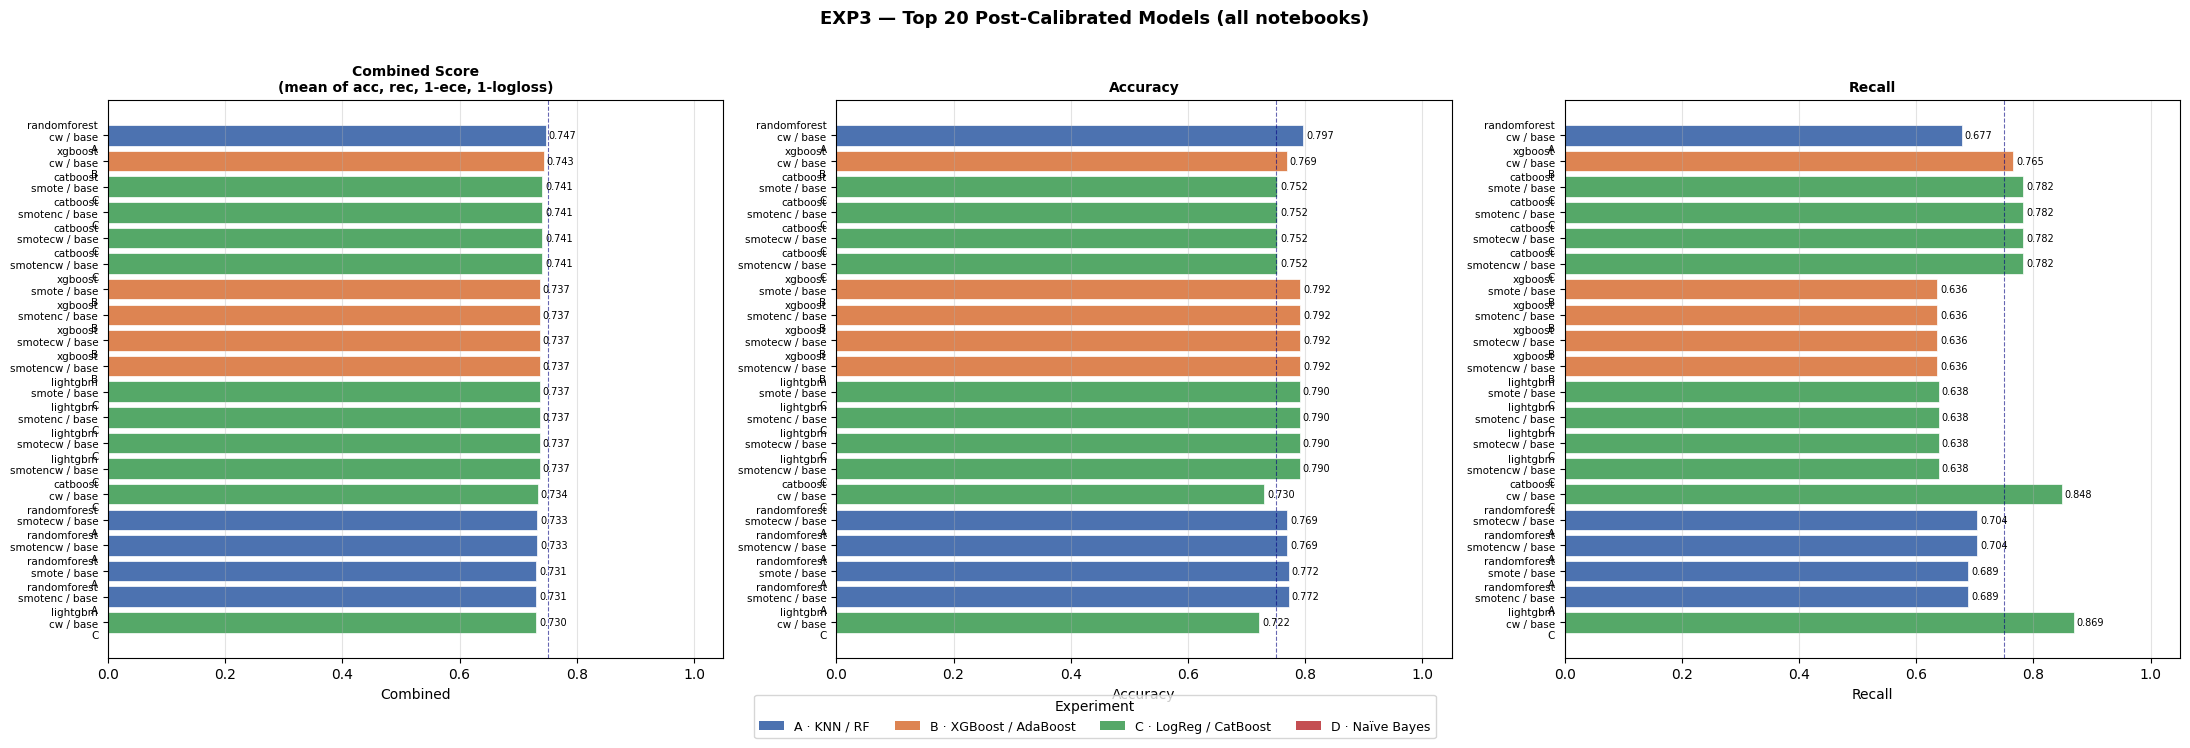

Saved: /workspace/Thesis-part-2/exp3_compiled/plots/top20_post_cal_bar.png


In [14]:
# ── Top-20 by combined score ───────────────────────────────────────────────────
top20 = post_all.head(20).copy()
top20['label'] = (
    top20['model'] + '\n' +
    top20['sampling'] + ' / ' +
    top20['calibration'] + '\n' +
    top20['experiment'].str.extract(r'^(\w+)', expand=False)
)

colors_exp = {
    'A · KNN / RF':            '#4C72B0',
    'B · XGBoost / AdaBoost':  '#DD8452',
    'C · LogReg / CatBoost':   '#55A868',
    'D · Naïve Bayes':         '#C44E52',
}
bar_colors = [colors_exp[e] for e in top20['experiment']]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, metric, title in zip(
    axes,
    ['combined', 'accuracy', 'recall'],
    ['Combined Score\n(mean of acc, rec, 1-ece, 1-logloss)', 'Accuracy', 'Recall']
):
    bars = ax.barh(range(len(top20)), top20[metric], color=bar_colors,
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['label'], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel(metric.capitalize(), fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.35)
    ax.axvline(x=0.75, color='navy', linewidth=0.8, linestyle='--', alpha=0.6)
    for bar, val in zip(bars, top20[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=lbl) for lbl, c in colors_exp.items()]
fig.legend(handles=legend_handles, title='Experiment', loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('EXP3 — Top 20 Post-Calibrated Models (all notebooks)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
_p = PLOT_DIR / 'top20_post_cal_bar.png'
plt.savefig(_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_p}')

## 4 · Per-Model Mean Metrics — Post-Calibration Heatmap

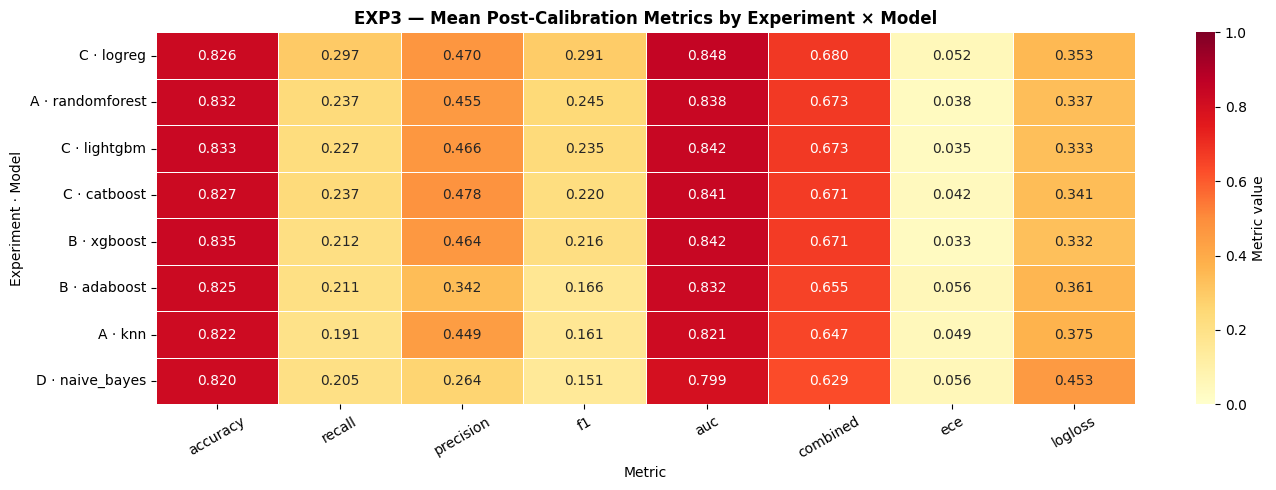

Saved: /workspace/Thesis-part-2/exp3_compiled/plots/post_cal_heatmap_exp_model.png


In [15]:
# ── Mean metrics per (experiment, model) ─────────────────────────────────────
post_all['exp_model'] = (
    post_all['experiment'].str.extract(r'^(\w+)', expand=False) + ' · ' +
    post_all['model']
)

agg = (
    post_all
    .groupby('exp_model')[METRIC_COLS + ['combined']]
    .mean()
    .sort_values('combined', ascending=False)
)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(5, len(agg) * 0.55)))
hm_data = agg[['accuracy', 'recall', 'precision', 'f1', 'auc', 'combined', 'ece', 'logloss']]
sns.heatmap(
    hm_data, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, vmin=0.0, vmax=1.0,
    cbar_kws={'label': 'Metric value'}
)
ax.set_title('EXP3 — Mean Post-Calibration Metrics by Experiment × Model',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Metric')
ax.set_ylabel('Experiment · Model')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
_p = PLOT_DIR / 'post_cal_heatmap_exp_model.png'
plt.savefig(_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_p}')

## 5 · Calibration Method Comparison — ECE & Log-Loss

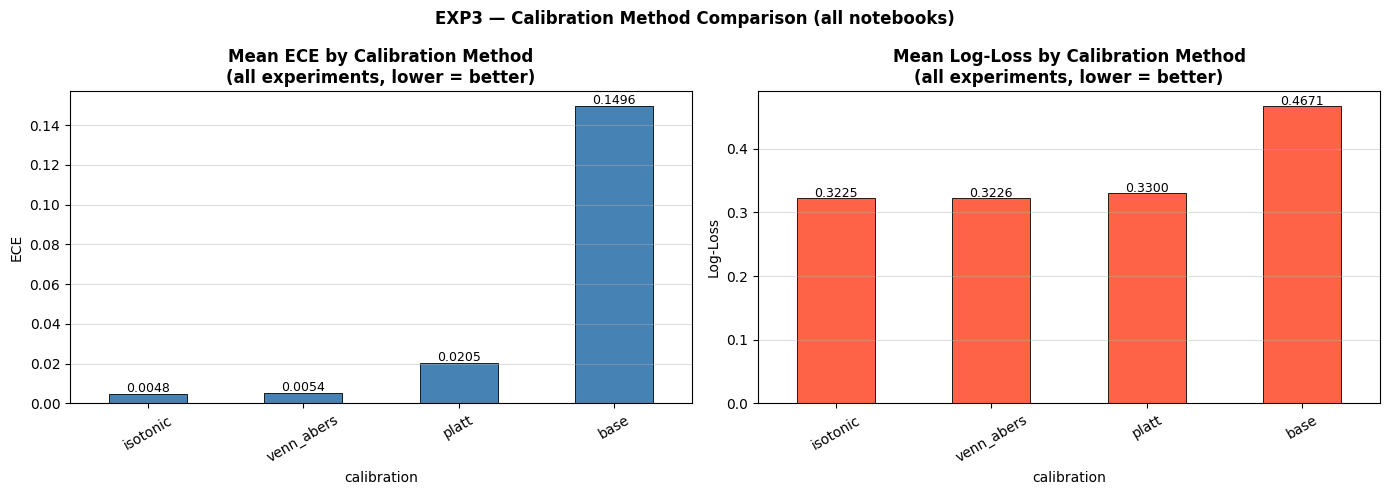

Saved: /workspace/Thesis-part-2/exp3_compiled/plots/calibration_method_comparison.png


In [16]:
# ── Mean ECE and Log-Loss per calibration method (across all experiments) ─────
cal_agg = (
    post_all
    .groupby('calibration')[['ece', 'logloss', 'accuracy', 'recall']]
    .mean()
    .sort_values('ece')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cal_agg['ece'].plot(kind='bar', ax=axes[0], color='steelblue',
                    edgecolor='black', linewidth=0.6)
axes[0].set_title('Mean ECE by Calibration Method\n(all experiments, lower = better)',
                   fontweight='bold')
axes[0].set_ylabel('ECE')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.4)
for i, v in enumerate(cal_agg['ece']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

cal_agg['logloss'].plot(kind='bar', ax=axes[1], color='tomato',
                         edgecolor='black', linewidth=0.6)
axes[1].set_title('Mean Log-Loss by Calibration Method\n(all experiments, lower = better)',
                   fontweight='bold')
axes[1].set_ylabel('Log-Loss')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.4)
for i, v in enumerate(cal_agg['logloss']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('EXP3 — Calibration Method Comparison (all notebooks)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
_p = PLOT_DIR / 'calibration_method_comparison.png'
plt.savefig(_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_p}')

## 6 · Pre vs Post Calibration Accuracy & Recall — By Experiment

Best metric per experiment (pre vs post calibration):


,pre_accuracy,pre_recall,pre_auc,pre_combined,post_accuracy,post_recall,post_auc,post_combined
experiment,,,,,,,,
A · KNN / RF,0.8247,0.8836,0.8487,0.7749,0.8488,0.8471,0.8487,0.7470
B · XGBoost / AdaBoost,0.8262,0.8791,0.8519,0.7712,0.8502,0.8645,0.8519,0.7432
C · LogReg / CatBoost,0.8335,0.8749,0.8522,0.7714,0.8506,0.8686,0.8522,0.7407
D · Naïve Bayes,0.7152,0.7949,0.8094,0.6710,0.8493,0.7451,0.8091,0.6455


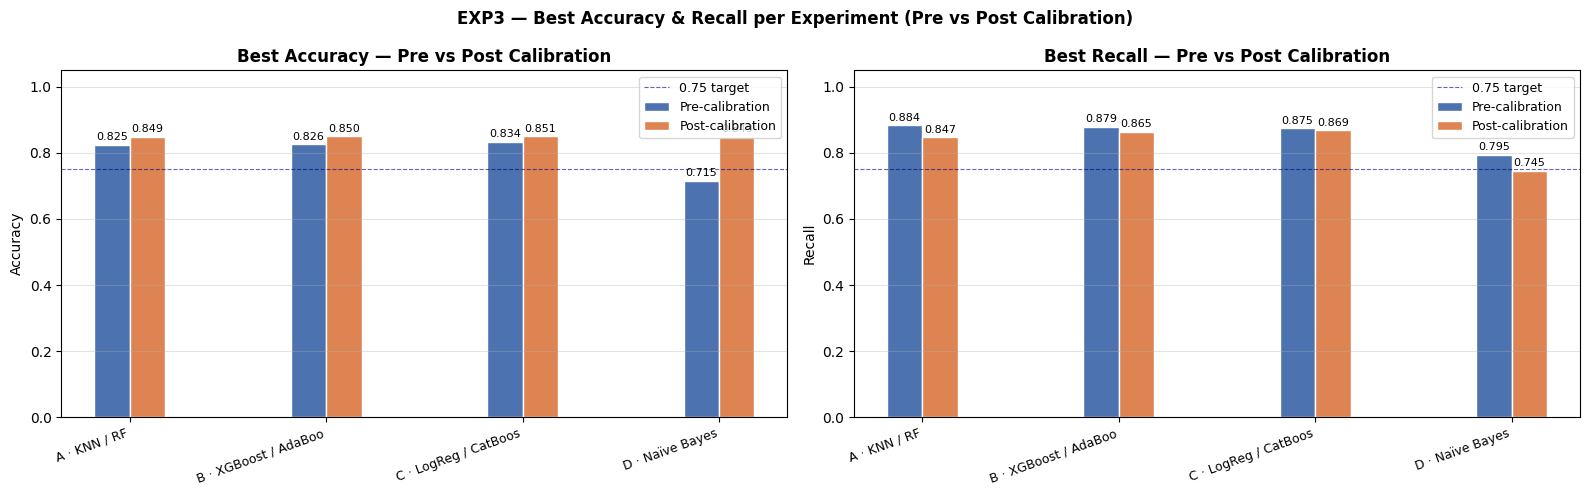

Saved: /workspace/Thesis-part-2/exp3_compiled/plots/pre_vs_post_cal_by_experiment.png


In [17]:
# ── Compare best-per-experiment before and after calibration ─────────────────
pre_best = (
    pre_all
    .groupby('experiment')[['accuracy', 'recall', 'auc', 'combined']]
    .max()
    .rename(columns=lambda c: 'pre_' + c)
)
post_best = (
    post_all
    .groupby('experiment')[['accuracy', 'recall', 'auc', 'combined']]
    .max()
    .rename(columns=lambda c: 'post_' + c)
)

compare = pre_best.join(post_best)
print('Best metric per experiment (pre vs post calibration):')
display(compare.round(4))

# ── Grouped bar chart ─────────────────────────────────────────────────────────
exps = compare.index.tolist()
x = np.arange(len(exps))
width = 0.18

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(axes, ['accuracy', 'recall'], ['Accuracy', 'Recall']):
    ax.bar(x - width/2, compare[f'pre_{metric}'],  width, label='Pre-calibration',
           color='#4C72B0', edgecolor='white')
    ax.bar(x + width/2, compare[f'post_{metric}'], width, label='Post-calibration',
           color='#DD8452', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([e[:20] for e in exps], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'Best {title} — Pre vs Post Calibration', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.75, color='navy', linewidth=0.8, linestyle='--', alpha=0.6, label='0.75 target')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.35)
    for rect in ax.patches:
        h = rect.get_height()
        if h > 0.01:
            ax.text(rect.get_x() + rect.get_width()/2, h + 0.008,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('EXP3 — Best Accuracy & Recall per Experiment (Pre vs Post Calibration)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
_p = PLOT_DIR / 'pre_vs_post_cal_by_experiment.png'
plt.savefig(_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_p}')

## 7 · Sampling Strategy Comparison — Post-Calibration

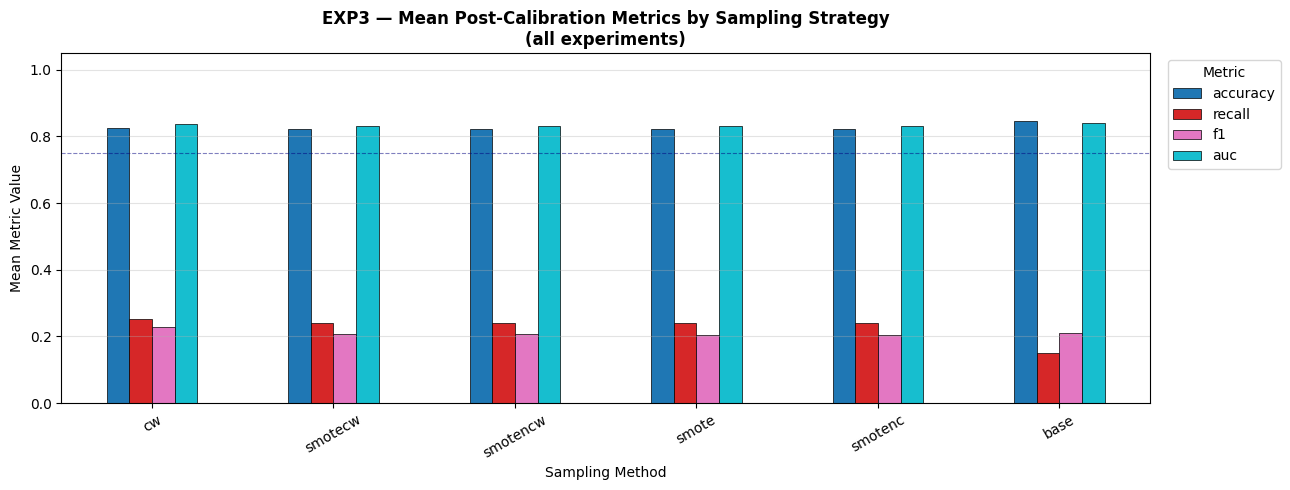

Saved: /workspace/Thesis-part-2/exp3_compiled/plots/sampling_strategy_comparison.png


In [18]:
# ── Mean accuracy & recall per sampling method (post-cal, all experiments) ───
samp_agg = (
    post_all
    .groupby('sampling')[['accuracy', 'recall', 'f1', 'auc']]
    .mean()
    .sort_values('recall', ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))

samp_agg[['accuracy', 'recall', 'f1', 'auc']].plot(
    kind='bar', ax=ax,
    colormap='tab10',
    edgecolor='black', linewidth=0.5
)
ax.set_title('EXP3 — Mean Post-Calibration Metrics by Sampling Strategy\n(all experiments)',
             fontweight='bold')
ax.set_xlabel('Sampling Method')
ax.set_ylabel('Mean Metric Value')
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 1.05)
ax.axhline(0.75, color='navy', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
_p = PLOT_DIR / 'sampling_strategy_comparison.png'
plt.savefig(_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_p}')

## 8 · Overall Best Model Summary

In [ ]:
# ── Single best model across all experiments ──────────────────────────────────
best_row = post_all.iloc[0]

print('=' * 90)
print('OVERALL BEST POST-CALIBRATED MODEL (across all 4 notebooks)')
print('=' * 90)
print(f"  Experiment  : {best_row['experiment']}")
print(f"  Model       : {best_row['model']}")
print(f"  Sampling    : {best_row['sampling']}")
print(f"  Calibration : {best_row['calibration']}")
print(f"  Accuracy    : {best_row['accuracy']:.4f}")
print(f"  Recall      : {best_row['recall']:.4f}")
print(f"  Precision   : {best_row['precision']:.4f}")
print(f"  F1          : {best_row['f1']:.4f}")
print(f"  AUC         : {best_row['auc']:.4f}")
print(f"  ECE         : {best_row['ece']:.4f}")
print(f"  Log-Loss    : {best_row['logloss']:.4f}")
print(f"  Combined    : {best_row['combined']:.4f}")

print('\n' + '-' * 50)
print('Best per experiment (highest combined score):')

# drop_duplicates on experiment after sorting — avoids pandas groupby key-drop bug
top_per_exp = (
    post_all
    .reset_index(drop=True)
    .sort_values('combined', ascending=False)
    .drop_duplicates(subset='experiment', keep='first')
    .sort_values('combined', ascending=False)
    .reset_index(drop=True)
)

display(top_per_exp[[
    'experiment', 'model', 'sampling', 'calibration',
    'accuracy', 'recall', 'f1', 'auc', 'ece', 'logloss', 'combined'
]])

# Save summary
_out = OUT_DIR / 'best_per_experiment_summary.csv'
top_per_exp.to_csv(_out, index=False)
print(f'\nSaved summary → {_out}')
print(f'\nAll compiled CSVs in: {OUT_DIR}')
print(f'All compiled plots in: {PLOT_DIR}')


OVERALL BEST POST-CALIBRATED MODEL (across all 4 notebooks)
  Experiment  : A · KNN / RF
  Model       : randomforest
  Sampling    : cw
  Calibration : base
  Accuracy    : 0.7968
  Recall      : 0.6774
  Precision   : 0.4005
  F1          : 0.5034
  AUC         : 0.8487
  ECE         : 0.1171
  Log-Loss    : 0.3691
  Combined    : 0.7470

--------------------------------------------------
Top-5 per experiment (best combined score):


KeyError: "['experiment'] not in index"